# RNA Co-Generation dataset analysis

We use RNASolo2 from https://rnasolo.cs.put.poznan.pl/archive in a similar manner to RiboGen. 
Data is preprocessed in `./dataset.py` to generate $S$, $X$ and $V$ matrices.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
filtered = np.load('dataset/dataset.npz')

S = filtered['S']
S_mask = S != -1
X = filtered['X']
V = filtered['V']
X_SCALE = filtered['x_scale']
V_SCALE = filtered['v_scale']

X_scaled = X * X_SCALE
V_scaled = V * V_SCALE

residue_names = filtered['residue_names']
ids = filtered['ids']

assert ids.shape[0] == S.shape[0]

(S.shape, X.shape, V.shape,

 residue_names.shape, ids.shape)

((10287, 2000),
 (10287, 2000, 3),
 (10287, 2000, 27, 3),
 (10287, 2000),
 (10287,))

Number of rows: 10287
Number of unique sequences: 3783


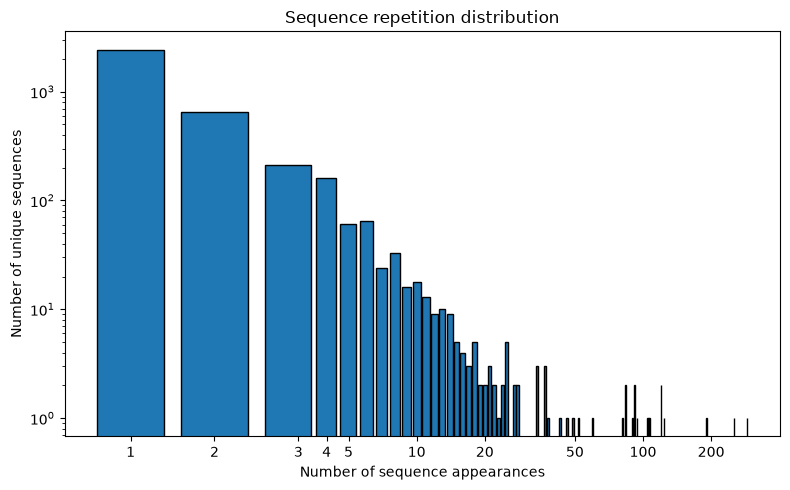

In [3]:
# Count how many times each sequence appears in the filtered dataset
unique_sequences, sequence_counts = np.unique(
    S, axis=0, return_counts=True
)

# Number of unique sequences that occur once, twice, three times, etc.
repetition_counts, num_sequences_with_repetition = np.unique(
    sequence_counts, return_counts=True
)

print(f"Number of rows: {S.shape[0]}")
print(f"Number of unique sequences: {unique_sequences.shape[0]}")

plt.figure(figsize=(8, 5))
plt.bar(
    repetition_counts,
    num_sequences_with_repetition,
    width=0.8,
    edgecolor="black",
)
plt.xlabel("Number of sequence appearances")
plt.ylabel("Number of unique sequences")
plt.title("Sequence repetition distribution")
plt.xscale("symlog", linthresh=3)
plt.yscale("log")
plt.xticks(
    [1, 2, 3, 4, 5, 10, 20, 50, 100, 200],
    ["1", "2", "3", "4", "5", "10", "20", "50", "100", "200"],
)
plt.tight_layout()
plt.show()

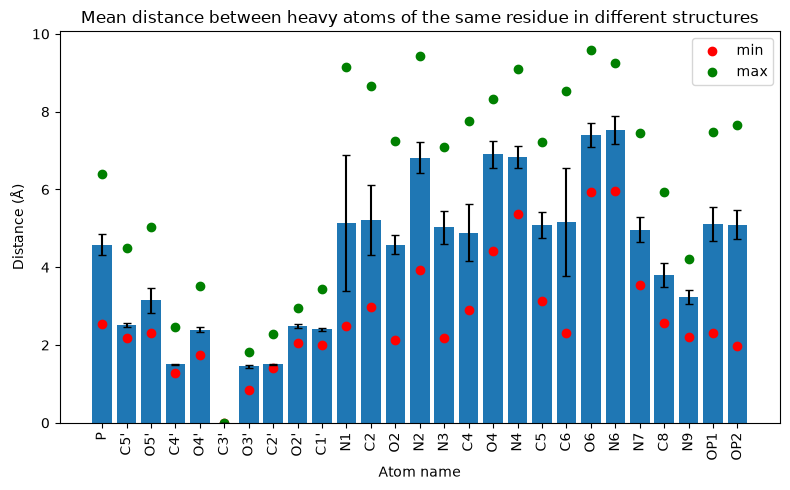

In [4]:
# Distance in Amstrongs between heavy atoms of the same residue in different structures and center C3'
from dataset import ATOM_NAMES
atom_distances = np.linalg.norm(V_scaled, axis=-1)
pos_mean = np.nanmean(atom_distances, axis=(0, 1))
pos_std = np.nanstd(atom_distances, axis=(0, 1))
pos_max = np.nanmax(atom_distances, axis=(0, 1))
pos_min = np.nanmin(atom_distances, axis=(0, 1))

plt.figure(figsize=(8, 5))
plt.bar(
    np.arange(len(ATOM_NAMES)),
    pos_mean)
plt.errorbar(
    np.arange(len(ATOM_NAMES)),
    pos_mean,
    yerr=pos_std,
    fmt='none',
    ecolor='black',
    capsize=3,
)
# add min and max as dots per atom
plt.scatter(
    np.arange(len(ATOM_NAMES)),
    pos_min,
    color='red',
    label='min',
)
plt.scatter(
    np.arange(len(ATOM_NAMES)),
    pos_max,
    color='green',
    label='max',
)
plt.xticks(np.arange(len(ATOM_NAMES)), ATOM_NAMES, rotation=90)
plt.xlabel("Atom name")
plt.ylabel("Distance (Å)")
plt.title("Mean distance between heavy atoms of the same residue in different structures")
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# Average distance between all structure atoms for identical sequences
def rsmd_matrix(A):
    """All-pairs superposed RMSD for one sequence's conformers. A: (C, L, 3)."""
    C, L, _ = A.shape
    Ac = A.astype(np.float64)
    Ac -= Ac.mean(axis=1, keepdims=True)                 # centre each structure

    P = Ac.transpose(0, 2, 1).reshape(C * 3, L)          # (C*3, L)
    G = (P @ P.T).reshape(C, 3, C, 3).transpose(0, 2, 1, 3)   # block [i,j] = A_i^T A_j

    U, s, Vt = np.linalg.svd(G.reshape(-1, 3, 3))
    d = np.sign(np.linalg.det(Vt.transpose(0, 2, 1) @ U.transpose(0, 2, 1)))
    trace = s[:, 0] + s[:, 1] + d * s[:, 2]

    nrm2 = (Ac ** 2).sum(axis=(1, 2))
    msd = nrm2[:, None] + nrm2[None, :] - 2 * trace.reshape(C, C)
    return np.sqrt(np.maximum(msd, 0.0) / L)

unique_sequences, sequence_indices = np.unique(S, axis=0, return_inverse=True)


pair_rmsd = []

for g in range(len(unique_sequences)):
    rows = np.flatnonzero(sequence_indices == g)
    if len(rows) < 2:
        continue

    coords = [X_scaled[i][S_mask[i]] for i in rows]

    M = rsmd_matrix(np.array(coords))
    iu = np.triu_indices(len(coords), k=1) # dont take diagonal
    pair_rmsd.append(M[iu])

pair_rmsd = np.concatenate(pair_rmsd)

print(f"Same-sequence structure pairs: {len(pair_rmsd):,}")
print(f"RMSD  median {np.median(pair_rmsd):.3f} Å | mean {pair_rmsd.mean():.3f} Å | max {pair_rmsd.max():.2f} Å")
for cutoff in (0.5, 1, 2, 3, 5):
    print(f"  below {cutoff} Å: {100 * (pair_rmsd < cutoff).mean():5.1f}%")


bins = np.logspace(np.log10(0.05), np.log10(50), 60)
centres = np.sqrt(bins[:-1] * bins[1:])
counts, _ = np.histogram(pair_rmsd, bins=bins)

fig, (ax_hist, ax_line) = plt.subplots(1, 2, figsize=(13, 5))

ax_hist.step(centres, counts, where="mid")
ax_hist.set(xscale="log", yscale="log",
            xlabel="C3' RMSD after superposition (Å)", ylabel="structure pairs",
            title="Same-sequence structural variation")

grid = np.logspace(-2, 2, 400)
ax_line.plot(grid, [(pair_rmsd < x).mean() for x in grid])
ax_line.axvline(1.0, color="black", ls=":", lw=1, label="1 Å (crystallographic precision)")
ax_line.axvline(3.0, color="red", ls=":", lw=1, label="3 Å (real conformational change)")
ax_line.set(xscale="log", xlabel="C3' RMSD (Å)", ylabel="fraction of pairs below x",
            title=f"Cumulative, {len(pair_rmsd):,} pairs")
ax_line.legend()
for ax in (ax_hist, ax_line):
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'seq_len' is not defined

Mean sequence length: 312.35
Standard deviation of sequence lengths: 542.37
Number of duplicate rows in filtered dataset: 6504


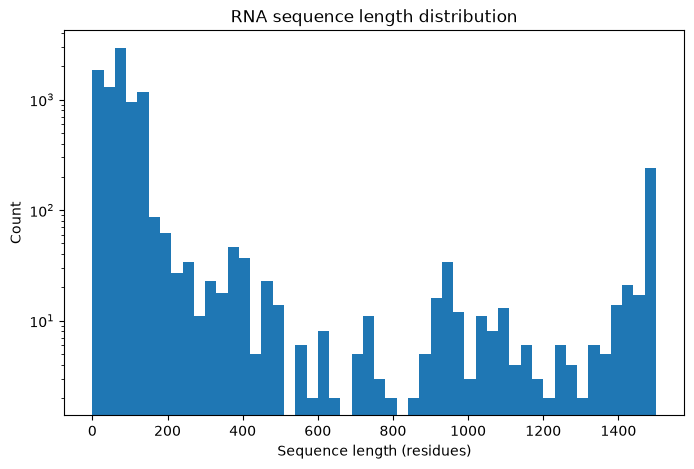

In [ ]:
# Sequence lengths of filtered dataset
seq_len = (S != -1).sum(axis=1)

# Mean and standard deviation of sequence lengths
mean_len = seq_len.mean()
std_len = seq_len.std()
print(f"Mean sequence length: {mean_len:.2f}")
print(f"Standard deviation of sequence lengths: {std_len:.2f}")

# Check for duplicate rows in the filtered and full arrays
unique_filtered = np.unique(S, axis=0).shape[0]
duplicates_filtered = S.shape[0] - unique_filtered
print(f"Number of duplicate rows in filtered dataset: {duplicates_filtered}")

plt.figure(figsize=(8, 5))
plt.hist(seq_len, bins=50, range=(0, 1500))
plt.xlabel("Sequence length (residues)")
plt.ylabel("Count")
plt.yscale("log")
plt.title("RNA sequence length distribution")
plt.show()

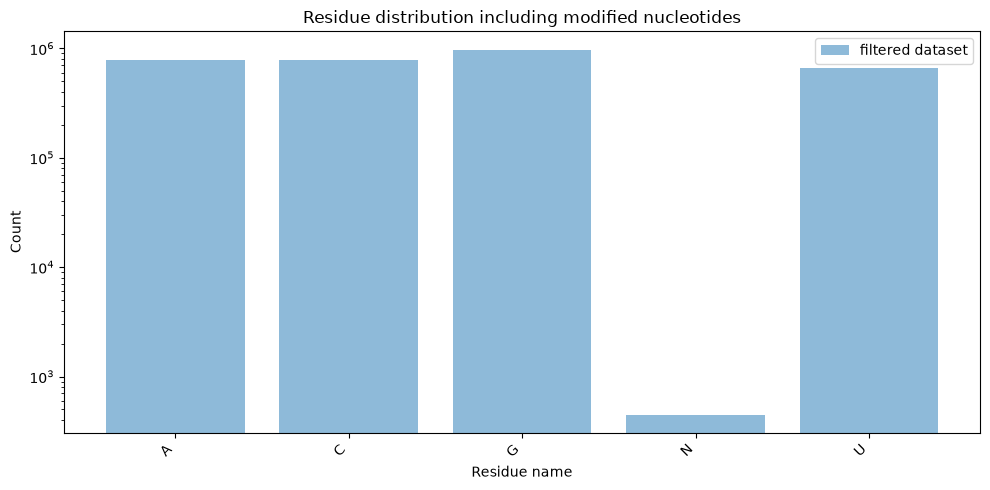

In [ ]:
# residue distribution using exact names, not just numeric codes

filtered_labels = residue_names[residue_names != ""].reshape(-1)

filtered_unique, filtered_counts = np.unique(filtered_labels, return_counts=True)

all_labels = list(dict.fromkeys(filtered_unique))
filtered_map = {label: count for label, count in zip(filtered_unique, filtered_counts)}

filtered_values = [filtered_map.get(label, 0) for label in all_labels]

plt.figure(figsize=(10, 5))
plt.bar(all_labels, filtered_values, label="filtered dataset", alpha=0.5)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Residue name")
plt.ylabel("Count")
plt.yscale("log")
plt.title("Residue distribution including modified nucleotides")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Analyze the position of center nucleotide C3'

# X 
c3_means = X[S_mask].mean(axis=0)
c3_std = X[S_mask].std(axis=0)

print(f"Mean position of C3' in filtered dataset: ({c3_means[0]:.2f}, {c3_means[1]:.2f}, {c3_means[2]:.2f})")
print(f"Standard deviation of C3' position in filtered dataset: ({c3_std[0]:.2f}, {c3_std[1]:.2f}, {c3_std[2]:.2f})")

Mean position of C3' in filtered dataset: (0.00, -0.00, 0.00)
Standard deviation of C3' position in filtered dataset: (1.03, 1.06, 0.90)


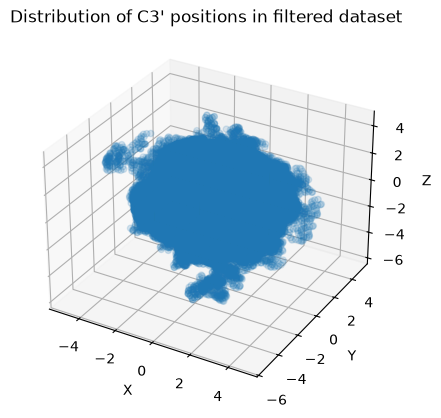

In [ ]:
# Plot the distribution of C3' positions in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[S_mask][:, 0], X[S_mask][:, 1], X[S_mask][:, 2], alpha=0.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Distribution of C3' positions in filtered dataset")
plt.show()

In [ ]:
# Analyze position of heavy atoms in the filtered dataset

heavy_atoms_positions = V[S_mask].reshape(-1, 3) 
heavy_atoms_positions = heavy_atoms_positions[~np.isnan(heavy_atoms_positions).any(axis=1)]

heavy_atoms_means = heavy_atoms_positions.mean(axis=0)
heavy_atoms_std = heavy_atoms_positions.std(axis=0)

print(f"Mean position of heavy atoms in filtered dataset: ({heavy_atoms_means[0]:.2f}, {heavy_atoms_means[1]:.2f}, {heavy_atoms_means[2]:.2f})")
print(f"Standard deviation of heavy atom positions in filtered dataset: ({heavy_atoms_std[0]:.2f}, {heavy_atoms_std[1]:.2f}, {heavy_atoms_std[2]:.2f})")

Mean position of heavy atoms in filtered dataset: (0.00, -0.00, -0.00)
Standard deviation of heavy atom positions in filtered dataset: (0.92, 0.91, 0.92)


In [ ]:
from scipy.spatial import cKDTree

radii = np.arange(0.1, 1.1, 0.1)
num_nodes = S_mask.sum(axis=1)

print(f"Mean number of nodes in filtered dataset: {num_nodes.mean():.2f}")

neighbor_counts = {radius: [] for radius in radii}

for sample_x, sample_mask in zip(X, S_mask):
    coords = sample_x[sample_mask]
    tree = cKDTree(coords)

    for radius in radii:
        counts = tree.query_ball_point(coords, radius, return_length=True) - 1
        neighbor_counts[radius].extend(counts)

for radius in radii:
    print(
        f"Mean number of neighbors for max_radius={radius:.1f}: "
        f"{np.mean(neighbor_counts[radius]):.2f}"
    )

Mean number of nodes in filtered dataset: 312.35


KeyboardInterrupt: 